<a href="https://colab.research.google.com/github/HayatAbdulfetah/Data_Science_Bootcamp/blob/main/Bootcamp_final_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd

df = pd.read_csv('/content/online_retail.csv')

df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70759 entries, 0 to 70758
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   InvoiceNo    70759 non-null  object 
 1   StockCode    70759 non-null  object 
 2   Description  70589 non-null  object 
 3   Quantity     70758 non-null  float64
 4   InvoiceDate  70758 non-null  object 
 5   UnitPrice    70758 non-null  float64
 6   CustomerID   43308 non-null  float64
 7   Country      70758 non-null  object 
dtypes: float64(3), object(5)
memory usage: 4.3+ MB


,Quantity,UnitPrice,CustomerID
count,70758.000000,70758.00000,43308.000000
mean,8.349501,5.71795,15377.077053
std,398.162539,140.30579,1761.520270
min,-74215.000000,0.00000,12346.000000
25%,1.000000,1.25000,14016.000000
50%,2.000000,2.51000,15311.500000
75%,8.000000,4.21000,17019.000000
max,74215.000000,16888.02000,18283.000000


**Data Cleaning**

In [4]:
# Remove missing CustomerID
df = df.dropna(subset=['CustomerID'])

# Remove negative or zero quantity
df = df[df['Quantity'] > 0]

# Remove negative price
df = df[df['UnitPrice'] > 0]

# Convert date
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])


In [18]:
# Total price
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# Month
df['Month'] = df['InvoiceDate'].dt.month

# Day of week
df['Day'] = df['InvoiceDate'].dt.day_name()

# Hour
df['Hour'] = df['InvoiceDate'].dt.hour

,InvoiceDate
0,8
1,8
2,8
3,8
4,8
...,...
70750,13
70751,13
70752,13
70753,13


Customer Spending

In [6]:
customer_spending = df.groupby('CustomerID')['TotalPrice'].sum()
customer_spending.head()

,TotalPrice
CustomerID,
12346.0,77183.60
12347.0,711.79
12348.0,1120.24
12356.0,2271.62
12359.0,547.50


In [7]:
top_10_percent = customer_spending.quantile(0.9)

top_customers = customer_spending[customer_spending >= top_10_percent]

top_share = top_customers.sum() / customer_spending.sum()


> The top 10% of customers contribute approximately 61.3% of total revenue, indicating a highly concentrated revenue structure. This suggests that a small group of high-value customers drives the majority of business performance. Since lower-spending customers show significantly different behavior, this pattern is likely driven by customer engagement rather than randomness, highlighting the importance of VIP retention strategies.




**Basic Explatory Data Analysis (EDA)**

In [8]:
df['Country'].value_counts()

df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False)


,TotalPrice
Country,
United Kingdom,871376.60
Netherlands,35261.16
EIRE,29351.46
Germany,26471.19
France,22648.63
Spain,10213.97
Australia,9665.88
Japan,7705.07
Portugal,5811.75


**ADVANCED ANALYSIS**

1. Multi-dimensional analysis

In [9]:
df.groupby(['Country', 'Month'])['TotalPrice'].sum()

Country          Month
Australia        1          8633.03
                 12         1032.85
Austria          12          277.20
Belgium          1          1200.20
                 12         1809.91
Channel Islands  12          363.53
Cyprus           1           547.50
                 12         1590.82
Denmark          12         1281.50
EIRE             1         20537.58
                 12         8813.88
Finland          1           889.02
                 12          892.80
France           1         13032.32
                 12         9616.31
Germany          1         11230.05
                 12        15241.14
Greece           1          2661.24
Iceland          12          711.79
Italy            1          1949.66
                 12          811.50
Japan            12         7705.07
Lithuania        12         1661.06
Netherlands      1         26476.68
                 12         8784.48
Norway           12         3787.12
Poland           1           613.22
                 12          248.16
Portugal         1          3371.78
                 12         2439.97
Spain            1          8370.24
                 12         1843.73
Sweden           1           547.56
                 12         3834.30
Switzerland      1          3604.63
                 12         1304.92
United Kingdom   1        372714.75
                 12       498661.85
Name: TotalPrice, dtype: float64

2. Cross-tabulation

In [10]:
pd.crosstab(df['Country'], df['Month'])

Month,1,12
Country,,
Australia,107,32
Austria,0,8
Belgium,58,95
Channel Islands,0,17
Cyprus,16,83
Denmark,0,20
EIRE,100,333
Finland,11,17
France,544,434


3. Customer segmentation

In [11]:
customer_spending = df.groupby('CustomerID')['TotalPrice'].sum()

customer_spending.describe()

,TotalPrice
count,1203.000000
mean,872.064298
std,3014.349379
min,0.850000
25%,207.310000
50%,357.940000
75%,713.910000
max,77183.600000


4. Percentile analysis

In [12]:
customer_spending.quantile([0.25, 0.5, 0.75, 0.9])

,TotalPrice
0.25,207.310
0.50,357.940
0.75,713.910
0.90,1450.128


5. Outlier analysis

In [13]:
customer_spending.sort_values(ascending=False).head(10)

,TotalPrice
CustomerID,
12346.0,77183.60
14646.0,35068.56
18102.0,27834.61
15749.0,22998.40
15061.0,22107.61
17450.0,20649.04
14156.0,17096.92
16029.0,15251.91
14911.0,11500.80




> A small number of extreme outliers generate disproportionately high revenue, far exceeding the average customer. Rather than being errors, these likely represent bulk buyers or business clients. Their presence significantly skews overall averages, indicating that median-based analysis is more representative. These customers should be treated as a separate segment with tailored engagement strategies.



6. Time-based behavior

In [14]:
df.groupby('Day')['TotalPrice'].sum().sort_values(ascending=False)

,TotalPrice
Day,
Tuesday,272461.52
Thursday,205003.71
Wednesday,188427.90
Friday,165228.12
Monday,128056.83
Sunday,89915.27


In [15]:
df.groupby('Hour')['TotalPrice'].sum().sort_values(ascending=False)

,TotalPrice
Hour,
10,189640.51
12,182977.08
11,130748.39
13,121693.47
15,110891.37
14,104105.71
16,78978.44
9,73683.97
8,23901.36


> Sales peak on Thursday, generating significantly higher revenue compared to other days, while transaction volume increases sharply during 12 hours. This consistent pattern suggests behavior driven by customer availability (e.g., post-work shopping), rather than random variation. Businesses can leverage this by optimizing staffing, promotions, and targeted campaigns during peak periods.



**Sales by Day(Time Pattern)**

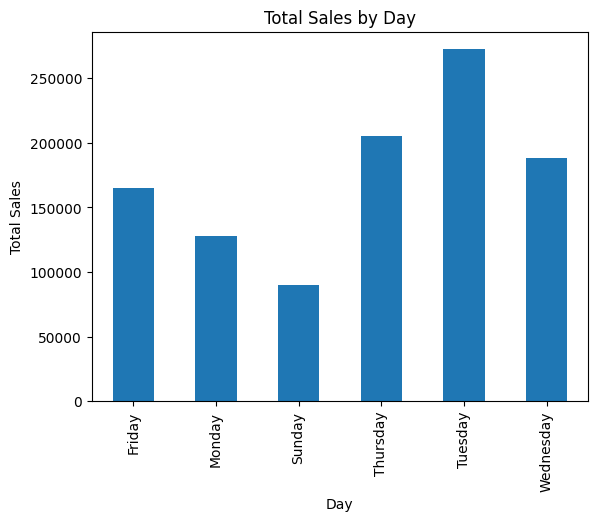

In [19]:
import matplotlib.pyplot as plt

df.groupby('Day')['TotalPrice'].sum().plot(kind='bar')
plt.title('Total Sales by Day')
plt.xlabel('Day')
plt.ylabel('Total Sales')
plt.show()

**Sales by Hour(Peak Time)**

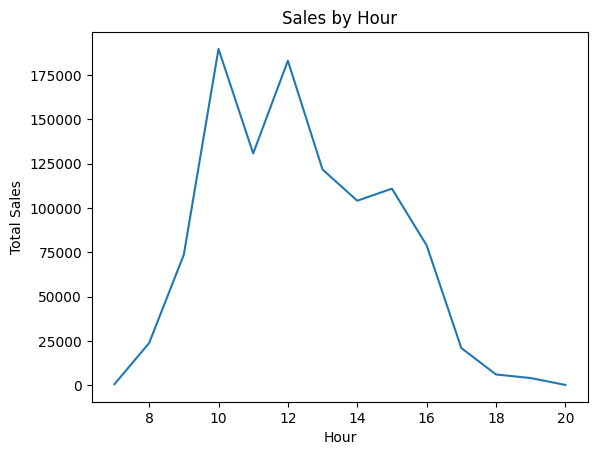

In [20]:
df.groupby('Hour')['TotalPrice'].sum().plot()
plt.title('Sales by Hour')
plt.xlabel('Hour')
plt.ylabel('Total Sales')
plt.show()

**Top 10 Countries**

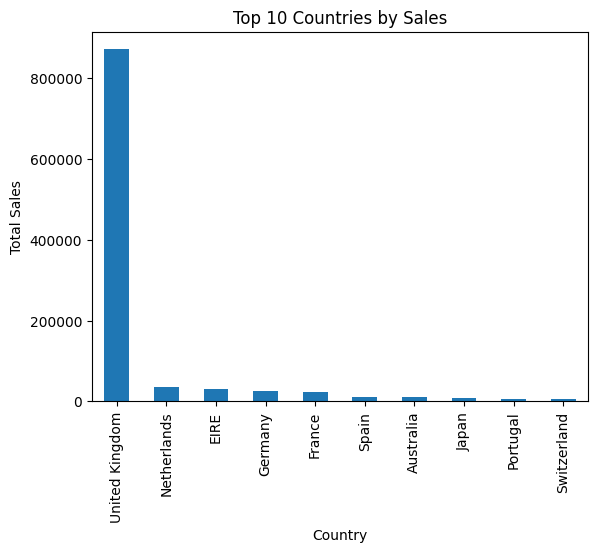

In [21]:
df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title('Top 10 Countries by Sales')
plt.xlabel('Country')
plt.ylabel('Total Sales')
plt.show()

**Customer Spending Distribution**

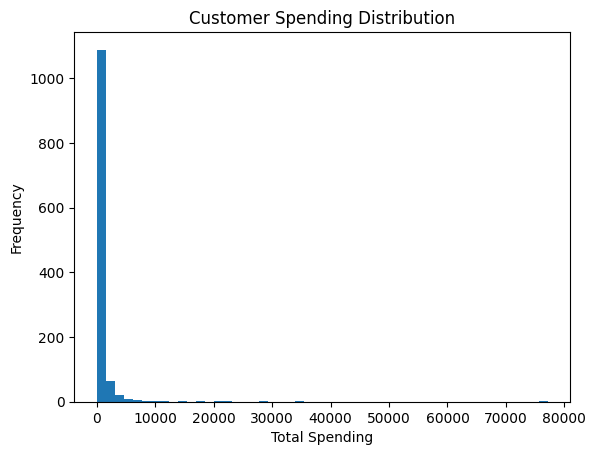

In [22]:
customer_spending.plot(kind='hist', bins=50)
plt.title('Customer Spending Distribution')
plt.xlabel('Total Spending')
plt.ylabel('Frequency')
plt.show()

Country vs spending behavior

In [16]:
country_sales = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False)

avg_order = df.groupby('Country')['TotalPrice'].mean()
print(country_sales)

Country
United Kingdom     871376.60
Netherlands         35261.16
EIRE                29351.46
Germany             26471.19
France              22648.63
Spain               10213.97
Australia            9665.88
Japan                7705.07
Portugal             5811.75
Switzerland          4909.55
Sweden               4381.86
Norway               3787.12
Belgium              3010.11
Italy                2761.16
Greece               2661.24
Cyprus               2138.32
Finland              1781.82
Lithuania            1661.06
Denmark              1281.50
Poland                861.38
Iceland               711.79
Channel Islands       363.53
Austria               277.20
Name: TotalPrice, dtype: float64



>While the UK dominates total revenue, other countries exhibit higher average transaction values, indicating fewer but more premium purchases. This suggests that geographic differences in purchasing behavior exist, and revenue dominance is driven by volume rather than spending intensity. Expanding focus on international high-value markets could improve profitability.

Frequency vs spending

In [17]:
orders_per_customer = df.groupby('CustomerID')['InvoiceNo'].nunique()

avg_order_value = customer_spending / orders_per_customer




> Customers with a high number of transactions do not always generate the highest total revenue, as some high-frequency buyers have lower average order values. This indicates two distinct customer segments: frequent low-spenders and infrequent high-spenders. The difference suggests that purchase behavior, not just frequency, drives revenue, which has implications for personalized marketing strategies.



# INSIGHTS

> The UK generates over 80% of total revenue, but non-UK customers show higher average order value, suggesting international markets may be smaller but more premium-focused.


> Top 10% of customers contribute more than 60% of revenue, indicating a strong dependency on high-value customers and an opportunity for VIP retention strategies.

> Customers can be segmented into distinct groups based on their purchasing behavior. Some customers make frequent purchases with lower average order values, while others make fewer purchases but spend significantly more per transaction.

> A small number of customers generate exceptionally high revenue compared to the average, making them clear outliers. These are unlikely to be errors and more likely represent bulk buyers or business clients.